# Color quantization

Importing libraries

In [ ]:
!pip install fuzzy-c-means

In [ ]:
import numpy as np
from PIL import Image
from fcmeans import FCM
import urllib.request

Getting and rescaling the image

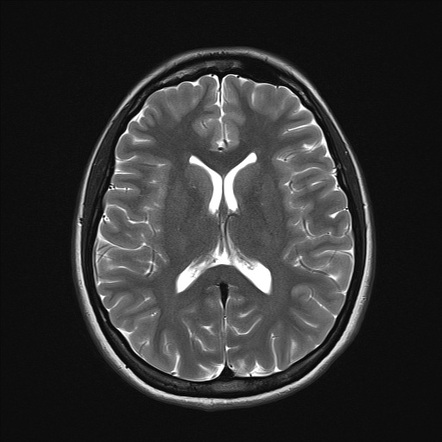

In [ ]:
urllib.request.urlretrieve('https://genovese.di.unimi.it/mri_1.jpg', 'image.jpg')
image = Image.open('image.jpg')           # read image (oarsman at https://omadson.github.io/photos/)
N, M = image.size                         # get the number of columns (N) and rows (M)
image                                     # show resized image

Transforming image into a data set

In [ ]:
X = (
    np.asarray(image)                              # convert a PIL image to np array
    .reshape((N*M, 1))                             # reshape the image to convert each pixel to an instance of a data set
)

Creating and fitting the model

In [ ]:
fcm = FCM(n_clusters=4, m=2)                      # create a FCM instance with 10 clusters
fcm.fit(X)                                         # fit the model

Pixel quantization

In [ ]:
U = fcm.u                     # (n_pixel, n_clusters)
centers = fcm.centers        # (n_clusters, 1)

# Media pesata fuzzy
transformed_X_fuzzy = U @ centers    # prodotto matriciale
transformed_X_fuzzy.shape = (N*M, 1)


Converting and saving image

In [ ]:
# quantized_array = (
#     transformed_X
#     .astype('uint8')                               # convert data points into 8-bit unsigned integers
#     .reshape((M, N))                            # reshape image
# )

# quantized_image = Image.fromarray(np.asarray(quantized_array))   # convert array into a PIL image object
# quantized_image.save('image_result.bmp') # save image
quantized_array_fuzzy = (
    transformed_X_fuzzy
    .astype(np.uint8)
    .reshape((M, N))
)

quantized_image_fuzzy = Image.fromarray(quantized_array_fuzzy)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Final result

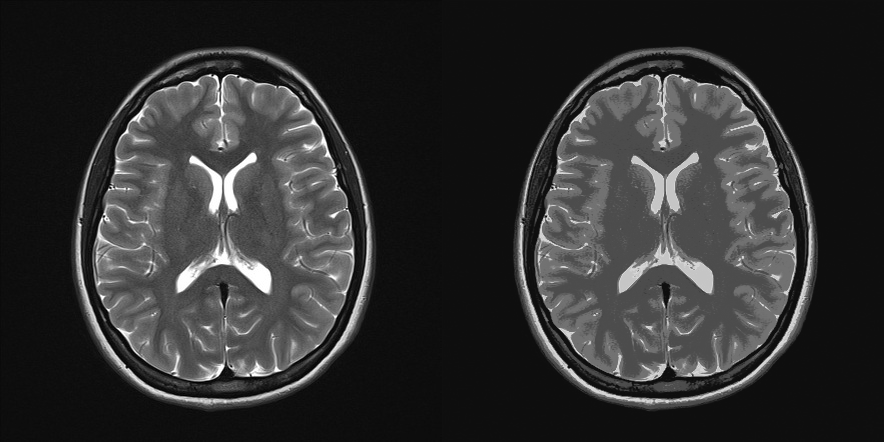

In [ ]:
side_by_side = Image.fromarray(
    np.hstack([
        np.array(image),
        np.array(quantized_image_fuzzy)
    ])
)
side_by_side

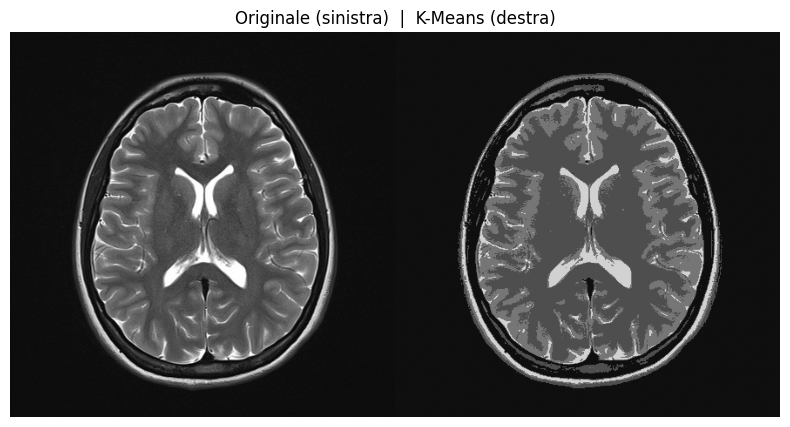

In [ ]:
import numpy as np
from PIL import Image
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# -------------------------
# Load image (grayscale)
# -------------------------
# image = Image.open("image.bmp").convert("L")   # assicurati sia grayscale
# M, N = image.size[1], image.size[0]            # altezza, larghezza

# -------------------------
# Image → dataset
# -------------------------
X = np.asarray(image).reshape((M * N, 1))

# -------------------------
# Hard K-Means
# -------------------------
kmeans = KMeans(
    n_clusters=4,
    random_state=0,
    n_init=10
)

kmeans.fit(X)

labels = kmeans.labels_                 # cluster assegnato a ogni pixel
centers = kmeans.cluster_centers_       # centroidi

# -------------------------
# Quantizzazione
# -------------------------
transformed_X = centers[labels]

quantized_array = (
    transformed_X
    .astype(np.uint8)
    .reshape((M, N))
)

quantized_image2 = Image.fromarray(quantized_array)
quantized_image2.save("image_kmeans.bmp")

# -------------------------
# Visualizzazione
# -------------------------
side_by_side = np.hstack([
    np.array(image),
    np.array(quantized_image2)
])

plt.figure(figsize=(10, 5))
plt.imshow(side_by_side, cmap="gray")
plt.title("Originale (sinistra)  |  K-Means (destra)")
plt.axis("off")
plt.show()


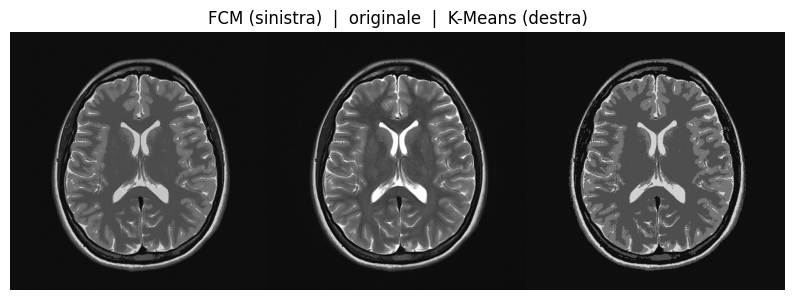

In [ ]:
side = np.hstack([
    np.array(quantized_image_fuzzy),
    np.array(image),
    np.array(quantized_image2)
])

plt.figure(figsize=(10, 5))
plt.imshow(side, cmap="gray")
plt.title("FCM (sinistra)  |  originale  |  K-Means (destra)")
plt.axis("off")
plt.show()